# Loyalty Member Segmentation: Finding Points-Purchase Targets

**Business question:** Which members of an airline loyalty program are most likely to buy points, and which of them have we not marketed to yet?

**Approach**
1. Combine four sources (member profile, flight transactions, points purchases, marketing history) into one row per member.
2. Engineer behavioural features covering flying, earning, redeeming and points buying.
3. Segment members with **K-Means clustering**.
4. Rank segments by **propensity to buy points** and pick the top segment.
5. Score members in that segment with a **purchase-propensity model**, then remove anyone who has already been emailed. The result is the target list.

> The data is **synthetic** (see `generate_data.py`). It copies the structure of a real partner dataset, which is confidential.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 50)

# Validated categorical palette (fixed order) and chart styling
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "axes.spines.top": False, "axes.axisbelow": True, "axes.spines.right": False, "font.size": 10,
})

DATA = Path("data")
SNAPSHOT = pd.Timestamp("2025-12-31")   # "today" for the analysis
WINDOW_START = pd.Timestamp("2024-01-01")
RANDOM_STATE = 42

## 1. Load the data
If the CSVs are missing, they are regenerated from the seeded generator.

In [2]:
if not (DATA / "members.csv").exists():
    import subprocess, sys
    subprocess.run([sys.executable, "generate_data.py"], check=True)

members = pd.read_csv(DATA / "members.csv", parse_dates=["enrol_date"])
flights = pd.read_csv(DATA / "flights.csv.gz", parse_dates=["booking_date", "departure_date", "return_date"])
purchases = pd.read_csv(DATA / "points_purchases.csv", parse_dates=["purchase_date"])
contacts = pd.read_csv(DATA / "marketing_contacts.csv.gz", parse_dates=["send_date"])

for name, df in [("members", members), ("flights", flights), ("purchases", purchases), ("contacts", contacts)]:
    print(f"{name:<10} {df.shape[0]:>8,} rows  x {df.shape[1]} cols")

members      40,000 rows  x 7 cols
flights     180,080 rows  x 14 cols
purchases    22,964 rows  x 7 cols
contacts     22,571 rows  x 6 cols


In [3]:
members.head()

,member_id,enrol_date,tier,age_band,home_airport,email_opt_in,points_balance
0,M0000001,2023-04-22,Base,35-44,YYC,True,16451
1,M0000002,2021-10-26,Silver,45-54,YYZ,False,3672
2,M0000003,2019-07-01,Base,45-54,YYZ,True,489
3,M0000004,2021-08-26,Base,45-54,YVR,True,14668
4,M0000005,2015-02-22,Base,35-44,YUL,True,9082


In [4]:
flights.head()

,booking_id,member_id,booking_date,departure_date,return_date,origin,destination,route_type,cabin_class,payment_type,fare_cad,fare_points,taxes_fees_cad,points_earned
0,B00000001,M0000006,2024-01-10,2024-01-31,2024-02-03,YUL,YOW,Domestic,Economy,Cash,801.75,0,0.00,1604
1,B00000002,M0000006,2024-02-27,2024-03-07,2024-03-13,YUL,YHZ,Domestic,Business,Cash,"2,691.63",0,0.00,13458
2,B00000003,M0000006,2024-02-28,2024-03-30,2024-04-08,YUL,SFO,Transborder,Economy,Cash,"1,289.29",0,0.00,2579
3,B00000004,M0000006,2024-03-06,2024-03-21,2024-03-27,YUL,LAS,Transborder,Business,Cash,"3,199.51",0,0.00,15998
4,B00000005,M0000006,2024-06-14,2024-07-12,2024-07-20,YUL,LAX,Transborder,Business,Cash,"4,052.87",0,0.00,20264


In [5]:
purchases.head()

,transaction_id,member_id,purchase_date,points_purchased,bonus_points,amount_usd,promo_flag
0,T0000001,M0000013,2024-12-11,25000,7500,549.89,True
1,T0000002,M0000014,2024-05-06,32000,0,969.13,False
2,T0000003,M0000014,2025-03-05,13000,9100,299.38,True
3,T0000004,M0000022,2024-09-01,8000,0,237.34,False
4,T0000005,M0000025,2024-04-28,12000,0,346.91,False


## 2. Data quality checks
Before engineering features: check nulls, duplicates, impossible dates and orphaned keys.

In [6]:
checks = {
    "duplicate member_id": members["member_id"].duplicated().sum(),
    "duplicate booking_id": flights["booking_id"].duplicated().sum(),
    "flights with unknown member": (~flights["member_id"].isin(members["member_id"])).sum(),
    "purchases with unknown member": (~purchases["member_id"].isin(members["member_id"])).sum(),
    "return before departure": (flights["return_date"] < flights["departure_date"]).sum(),
    "departure before booking": (flights["departure_date"] < flights["booking_date"]).sum(),
    "award flights with cash fare": ((flights["payment_type"] == "Points") & (flights["fare_cad"] > 0)).sum(),
    "negative points balance": (members["points_balance"] < 0).sum(),
}
pd.Series(checks, name="count").to_frame()

,count
duplicate member_id,0
duplicate booking_id,0
flights with unknown member,0
purchases with unknown member,0
return before departure,0
departure before booking,0
award flights with cash fare,0
negative points balance,0


In [7]:
# One-way trips have no return date, so these nulls are expected
flights.isna().sum()[lambda s: s > 0]

return_date    36192
dtype: int64

## 3. Feature engineering
Each member becomes one row. The features fall into four groups:

| Group | Features |
|---|---|
| **Flying** | flights, cash spend, avg fare, premium-cabin share, international share, avg trip length, booking lead time, days since last booking |
| **Earning / redeeming** | points earned, points redeemed, award-flight share, points balance |
| **Points buying** | purchases, points bought, $ spent, promo share, days since last purchase |
| **Profile** | tier, tenure |

Everything goes in a function with a `cutoff` date, so the same logic can rebuild features "as of" an earlier date for the propensity model in section 7.

In [8]:
TIER_ORDER = {"Base": 0, "Silver": 1, "Gold": 2, "Platinum": 3, "Elite": 4}

def build_features(cutoff, lookback_days=730):
    """Member-level features using activity in (cutoff - lookback, cutoff]."""
    start = cutoff - pd.Timedelta(days=lookback_days)
    f = flights[(flights["booking_date"] > start) & (flights["booking_date"] <= cutoff)].copy()
    p = purchases[(purchases["purchase_date"] > start) & (purchases["purchase_date"] <= cutoff)]

    f["is_award"] = f["payment_type"].eq("Points")
    f["is_premium"] = f["cabin_class"].ne("Economy")
    f["is_intl"] = f["route_type"].eq("International")
    f["lead_days"] = (f["departure_date"] - f["booking_date"]).dt.days
    f["trip_days"] = (f["return_date"] - f["departure_date"]).dt.days

    fa = f.groupby("member_id").agg(
        flights=("booking_id", "count"),
        award_flights=("is_award", "sum"),
        cash_spend_cad=("fare_cad", "sum"),
        points_earned=("points_earned", "sum"),
        points_redeemed=("fare_points", "sum"),
        premium_cabin_share=("is_premium", "mean"),
        intl_share=("is_intl", "mean"),
        avg_lead_days=("lead_days", "mean"),
        avg_trip_days=("trip_days", "mean"),
        last_booking=("booking_date", "max"),
    )
    cash = f[~f["is_award"]].groupby("member_id")["fare_cad"].mean().rename("avg_cash_fare_cad")

    pa = p.groupby("member_id").agg(
        purchases=("transaction_id", "count"),
        points_bought=("points_purchased", "sum"),
        purchase_spend_usd=("amount_usd", "sum"),
        promo_share=("promo_flag", "mean"),
        last_purchase=("purchase_date", "max"),
    )

    df = members.set_index("member_id").join([fa, cash, pa])
    count_cols = ["flights", "award_flights", "cash_spend_cad", "points_earned", "points_redeemed",
                  "purchases", "points_bought", "purchase_spend_usd"]
    df[count_cols] = df[count_cols].fillna(0)
    # Shares/averages are undefined with no activity: fill with 0 (no premium flying, no lead time, ...)
    df[["premium_cabin_share", "intl_share", "promo_share", "avg_lead_days", "avg_trip_days",
        "avg_cash_fare_cad"]] = df[["premium_cabin_share", "intl_share", "promo_share", "avg_lead_days",
                                    "avg_trip_days", "avg_cash_fare_cad"]].fillna(0)
    df["award_share"] = np.where(df["flights"] > 0, df["award_flights"] / df["flights"].clip(lower=1), 0)
    # Recency: members with no activity get lookback + 1 (i.e. "longer ago than the window")
    df["days_since_booking"] = (cutoff - df["last_booking"]).dt.days.fillna(lookback_days + 1)
    df["days_since_purchase"] = (cutoff - df["last_purchase"]).dt.days.fillna(lookback_days + 1)
    df["tier_rank"] = df["tier"].map(TIER_ORDER)
    df["tenure_years"] = (cutoff - df["enrol_date"]).dt.days / 365.25
    return df.drop(columns=["last_booking", "last_purchase"])

features = build_features(SNAPSHOT)
features.describe().T

,count,mean,min,25%,50%,75%,max,std
enrol_date,40000,2015-12-25 19:22:35.040000,2008-01-01 00:00:00,2011-12-25 00:00:00,2015-12-28 00:00:00,2019-12-25 00:00:00,2023-12-31 00:00:00,NaN
points_balance,"40,000.00","24,700.65",0.00,"2,876.00","9,908.50","21,189.25","1,376,246.00","58,261.53"
flights,"40,000.00",4.50,0.00,0.00,1.00,4.00,181.00,9.37
award_flights,"40,000.00",0.77,0.00,0.00,0.00,0.00,29.00,2.05
cash_spend_cad,"40,000.00","6,636.58",0.00,0.00,935.77,"4,439.76","321,280.03","18,063.38"
points_earned,"40,000.00","23,638.76",0.00,0.00,"1,888.00","10,053.00","1,211,201.00","73,279.46"
points_redeemed,"40,000.00","68,186.69",0.00,0.00,0.00,0.00,"3,184,000.00","207,907.49"
premium_cabin_share,"40,000.00",0.12,0.00,0.00,0.00,0.17,1.00,0.23
intl_share,"40,000.00",0.14,0.00,0.00,0.00,0.25,1.00,0.24
avg_lead_days,"40,000.00",42.35,0.00,0.00,40.73,69.43,347.00,41.93


### Distributions
The activity metrics are heavily right-skewed: most members fly rarely and a small group flies a lot. K-Means uses Euclidean distance, so these features get a `log1p` transform before scaling. Without it, a handful of extreme members would drive the clusters.

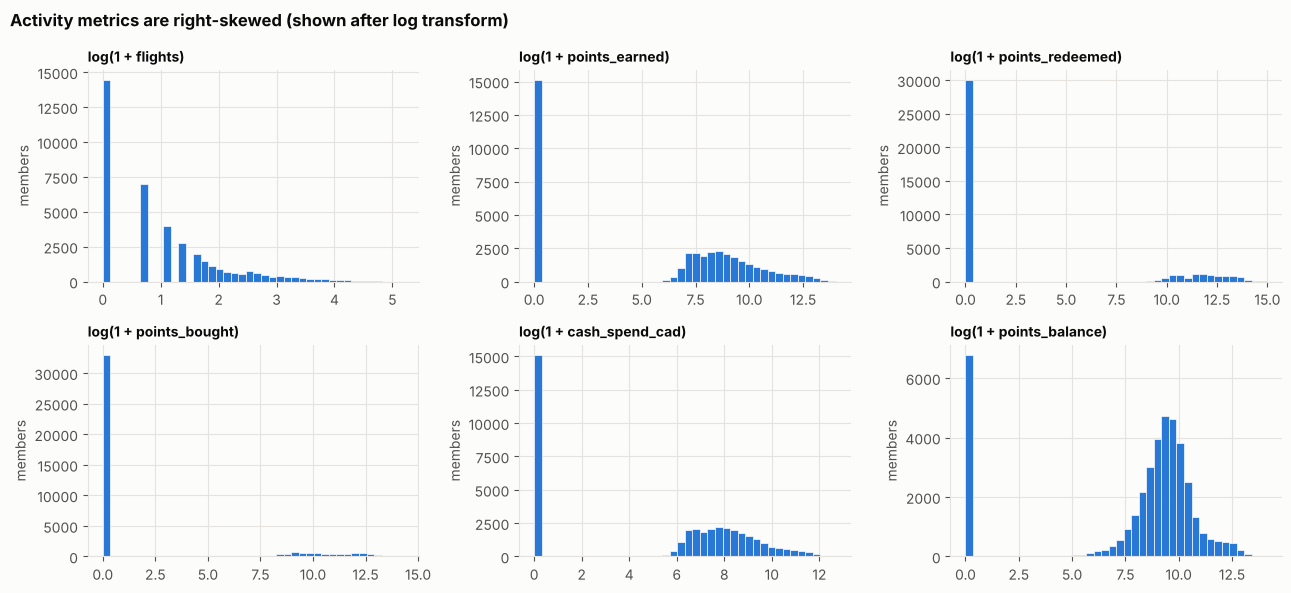

In [9]:
show = ["flights", "points_earned", "points_redeemed", "points_bought", "cash_spend_cad", "points_balance"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, show):
    ax.hist(np.log1p(features[col]), bins=40, color=PALETTE[0], edgecolor="#fcfcfb", linewidth=0.5)
    ax.set_title(f"log(1 + {col})", fontsize=10)
    ax.set_ylabel("members")
fig.suptitle("Activity metrics are right-skewed (shown after log transform)", x=0.01, ha="left",
             fontweight="bold", color=INK)
plt.tight_layout()

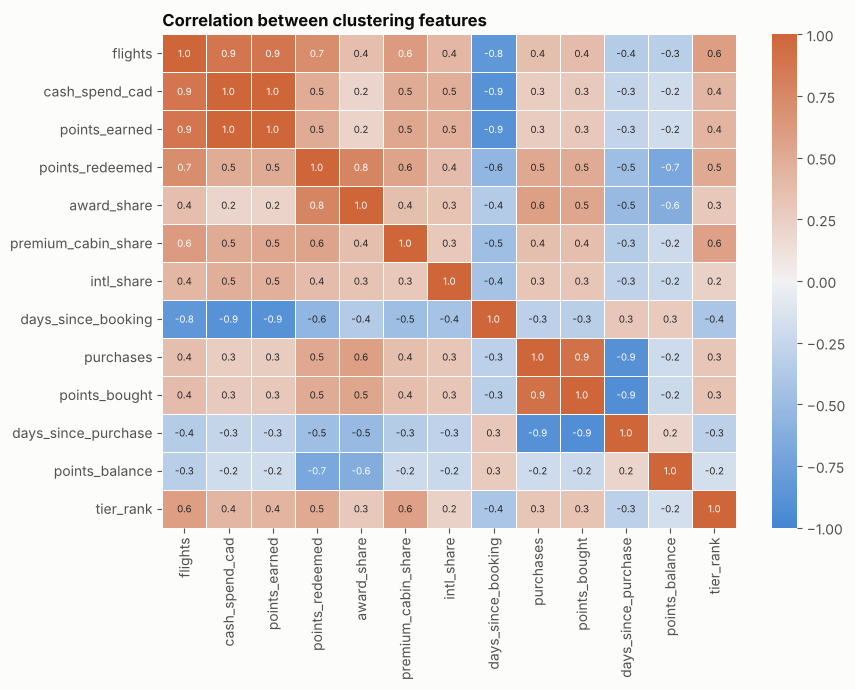

In [10]:
cluster_features = [
    "flights", "cash_spend_cad", "points_earned", "points_redeemed", "award_share",
    "premium_cabin_share", "intl_share", "days_since_booking",
    "purchases", "points_bought", "days_since_purchase", "points_balance", "tier_rank",
]
log_cols = ["flights", "cash_spend_cad", "points_earned", "points_redeemed",
            "purchases", "points_bought", "points_balance"]

corr = features[cluster_features].assign(**{c: np.log1p(features[c]) for c in log_cols}).corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap=sns.diverging_palette(250, 25, s=80, l=55, as_cmap=True), center=0,
            vmin=-1, vmax=1, annot=True, fmt=".1f", annot_kws={"size": 7}, linewidths=0.5)
plt.title("Correlation between clustering features"); plt.grid(False)
plt.tight_layout()

Flying volume, spend and points earned are strongly correlated with each other. Points buying is a separate axis of engagement, and that is the behaviour this project targets. Correlated inputs give "flying volume" extra weight in the distance metric. Section 5 checks this with PCA.

## 4. Prepare the feature matrix

In [11]:
X = features[cluster_features].copy()
X[log_cols] = np.log1p(X[log_cols])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(40000, 13)

## 5. Choosing the number of clusters
Two diagnostics:
- **Elbow (inertia):** the within-cluster sum of squares always falls as *k* grows. We look for the point where the gains flatten.
- **Silhouette score:** how well separated the clusters are, from -1 to 1. Computed on a 10k sample to save time.

The pick also has to be **actionable**. Marketing can run 4 to 6 personas; it cannot run 10.

k,2,3,4,5,6,7,8,9,10
inertia,"327,289.79","244,381.36","192,783.23","165,700.65","146,564.85","130,932.64","122,220.90","114,738.13","107,558.42"
silhouette,0.46,0.43,0.48,0.50,0.51,0.51,0.51,0.52,0.52


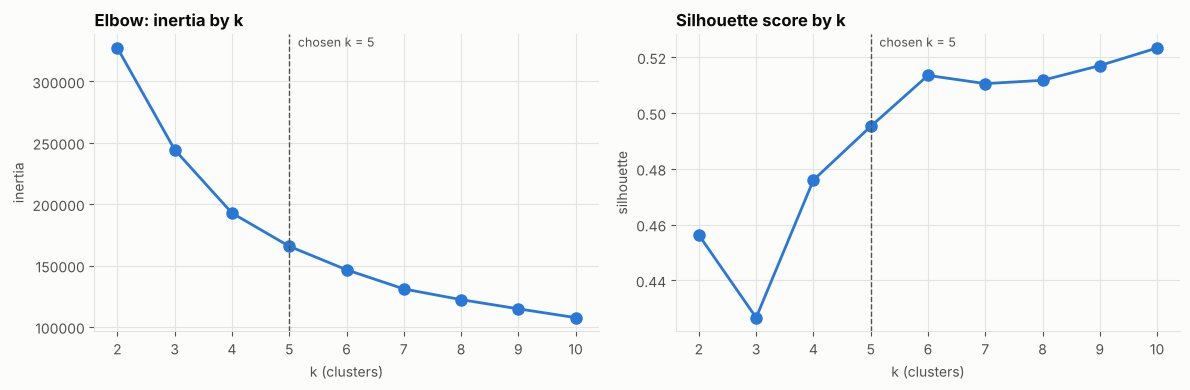

In [12]:
ks = range(2, 11)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_, sample_size=10_000, random_state=RANDOM_STATE))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(ks, inertia, marker="o", color=PALETTE[0], lw=2, ms=8)
a1.set(title="Elbow: inertia by k", xlabel="k (clusters)", ylabel="inertia")
a2.plot(ks, silhouette, marker="o", color=PALETTE[0], lw=2, ms=8)
a2.set(title="Silhouette score by k", xlabel="k (clusters)", ylabel="silhouette")
for a in (a1, a2):
    a.axvline(5, color=INK_2, ls="--", lw=1)
    a.annotate("chosen k = 5", xy=(5, a.get_ylim()[1]), xytext=(5.15, a.get_ylim()[1]),
               va="top", color=INK_2, fontsize=9)
plt.tight_layout()
pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": silhouette}).set_index("k").T

The elbow bends around **k = 4–5**. The silhouette score climbs to about 0.50 at k = 5 and then levels off: going to 10 clusters only gains about 0.02. Those extra clusters split low-activity members into slivers that marketing would treat the same way. **We use k = 5.**

In [13]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE).fit(X_scaled)
features["cluster"] = kmeans.labels_
features["cluster"].value_counts().sort_index()

cluster
0    14433
1     2927
2     4283
3    14817
4     3540
Name: count, dtype: int64

## 6. Profile and name the segments

In [14]:
profile_cols = ["flights", "cash_spend_cad", "avg_cash_fare_cad", "points_earned", "points_redeemed",
                "award_share", "premium_cabin_share", "intl_share", "days_since_booking",
                "purchases", "points_bought", "purchase_spend_usd", "days_since_purchase",
                "points_balance", "tier_rank"]
profile = features.groupby("cluster")[profile_cols].mean()
profile.insert(0, "members", features["cluster"].value_counts())
profile.insert(1, "pct_of_base", profile["members"] / len(features))
profile["buyer_rate"] = features.assign(b=features["purchases"] > 0).groupby("cluster")["b"].mean()
profile.T

cluster,0,1,2,3,4
members,"14,433.00","2,927.00","4,283.00","14,817.00","3,540.00"
pct_of_base,0.36,0.07,0.11,0.37,0.09
flights,0.00,26.03,10.04,2.58,6.36
cash_spend_cad,0.00,"51,512.38","11,460.04","2,862.16","6,552.10"
avg_cash_fare_cad,0.00,"2,156.01","1,887.89","1,034.57","1,221.76"
points_earned,0.00,"207,167.04","40,429.26","6,737.87","18,694.65"
points_redeemed,0.00,"170,273.08","414,785.06",557.11,"125,508.28"
award_share,0.00,0.07,0.47,0.00,0.38
premium_cabin_share,0.00,0.55,0.37,0.07,0.16
intl_share,0.00,0.21,0.37,0.17,0.27


In [15]:
# Name clusters by ranking their centroids, not by hard-coded cluster IDs,
# so labels stay correct if K-Means numbers the clusters differently.
names = {}
remaining = profile.copy()
def take(idx, name):
    global remaining
    names[idx] = name
    remaining = remaining.drop(idx)

take(remaining["buyer_rate"].idxmax(), "Engaged Points Buyers")
take(remaining["flights"].idxmin(), "Dormant")
take(remaining["flights"].idxmax(), "Frequent Premium Flyers")
take(remaining["award_share"].idxmax(), "Award Redeemers")
take(remaining.index[0], "Light Leisure Flyers")
profile["segment"] = pd.Series(names)
features["segment"] = features["cluster"].map(profile["segment"])

# Fixed segment order (and therefore fixed colours) used by every chart below
SEGMENTS = ["Engaged Points Buyers", "Award Redeemers", "Frequent Premium Flyers",
            "Light Leisure Flyers", "Dormant"]
SEG_COLOR = dict(zip(SEGMENTS, PALETTE))
profile.set_index("segment").loc[SEGMENTS, ["members", "pct_of_base", "flights", "points_redeemed",
                                             "buyer_rate", "purchases", "purchase_spend_usd"]]

,members,pct_of_base,flights,points_redeemed,buyer_rate,purchases,purchase_spend_usd
segment,,,,,,,
Engaged Points Buyers,4283,0.11,10.04,"414,785.06",1.00,4.60,"4,125.69"
Award Redeemers,3540,0.09,6.36,"125,508.28",0.07,0.07,26.51
Frequent Premium Flyers,2927,0.07,26.03,"170,273.08",0.19,0.21,98.63
Light Leisure Flyers,14817,0.37,2.58,557.11,0.09,0.10,28.75
Dormant,14433,0.36,0.00,0.00,0.04,0.06,30.57


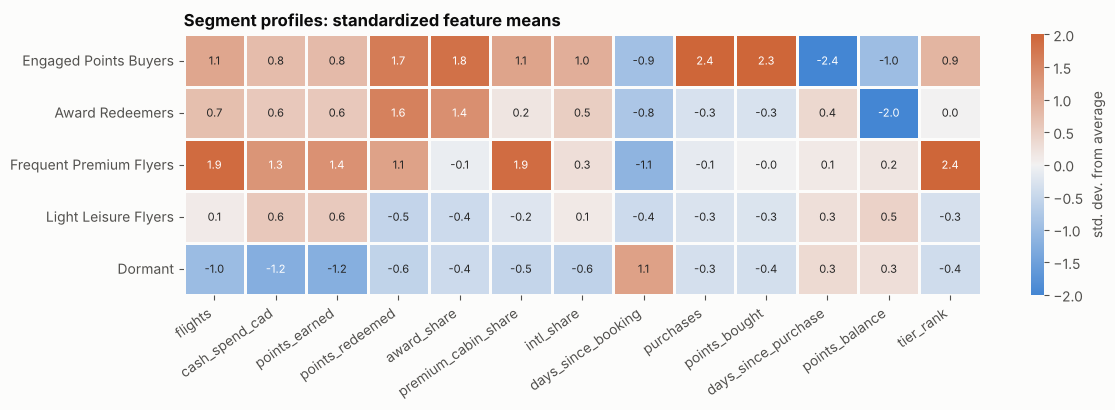

In [16]:
# Heatmap of how far each segment's average is from the population average, in standard deviations
z = pd.DataFrame(X_scaled, columns=cluster_features, index=features.index)
z["segment"] = features["segment"]
zprof = z.groupby("segment")[cluster_features].mean().loc[SEGMENTS]

plt.figure(figsize=(12, 4.2))
sns.heatmap(zprof, cmap=sns.diverging_palette(250, 25, s=80, l=55, as_cmap=True), center=0,
            vmin=-2, vmax=2, annot=True, fmt=".1f", annot_kws={"size": 8}, linewidths=1,
            linecolor="#fcfcfb", cbar_kws={"label": "std. dev. from average"})
plt.title("Segment profiles: standardized feature means"); plt.grid(False)
plt.ylabel(""); plt.xticks(rotation=35, ha="right")
plt.tight_layout()

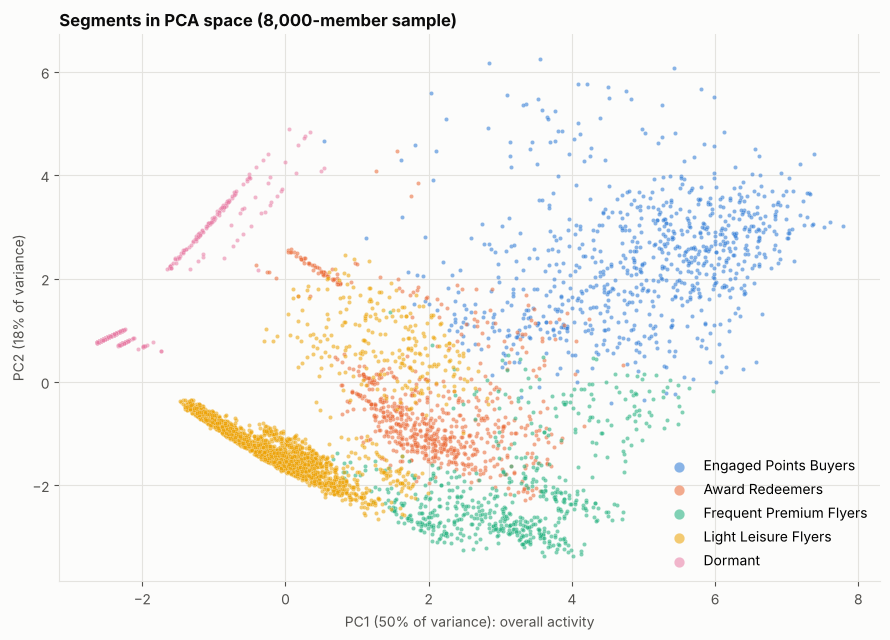

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
sample = np.random.default_rng(RANDOM_STATE).choice(len(pcs), 8000, replace=False)

fig, ax = plt.subplots(figsize=(9, 6.5))
for seg in SEGMENTS:
    idx = sample[features["segment"].to_numpy()[sample] == seg]
    ax.scatter(pcs[idx, 0], pcs[idx, 1], s=9, alpha=0.55, color=SEG_COLOR[seg], label=seg,
               edgecolors="#fcfcfb", linewidths=0.2)
ev = pca.explained_variance_ratio_
ax.set(xlabel=f"PC1 ({ev[0]:.0%} of variance): overall activity",
       ylabel=f"PC2 ({ev[1]:.0%} of variance)", title="Segments in PCA space (8,000-member sample)")
ax.legend(frameon=False, markerscale=2.5, loc="best")
plt.tight_layout()

### Segment summary

| Segment | Who they are |
|---|---|
| **Engaged Points Buyers** | Fly regularly, book about half their trips as award flights (often international or premium cabin), and buy points repeatedly and recently. Every member of this segment is a buyer. The most engaged group in the program. |
| **Award Redeemers** | Redeem points for flights but rarely buy. Their balances are close to zero after redeeming, so they are a natural audience for a top-up offer. |
| **Frequent Premium Flyers** | Highest flight volume, cash spend and tier; mostly premium cabins. They earn so many points that they seldom need to buy. |
| **Light Leisure Flyers** | A few economy trips; small balances; almost never buy. |
| **Dormant** | No flight activity in the window. Reactivation candidates, not a points-sales audience. |

## 7. Which segment has the highest propensity to buy points?
Segments are ranked on points-buying behaviour: share of members who bought, purchases per member, and revenue per member.

In [18]:
seg = features.groupby("segment").agg(
    members=("purchases", "size"),
    buyer_rate=("purchases", lambda s: (s > 0).mean()),
    purchases_per_member=("purchases", "mean"),
    revenue_per_member_usd=("purchase_spend_usd", "mean"),
    total_revenue_usd=("purchase_spend_usd", "sum"),
).loc[SEGMENTS]
seg["share_of_members"] = seg["members"] / seg["members"].sum()
seg["share_of_revenue"] = seg["total_revenue_usd"] / seg["total_revenue_usd"].sum()
seg.sort_values("revenue_per_member_usd", ascending=False)

,members,buyer_rate,purchases_per_member,revenue_per_member_usd,total_revenue_usd,share_of_members,share_of_revenue
segment,,,,,,,
Engaged Points Buyers,4283,1.00,4.60,"4,125.69","17,670,337.22",0.11,0.93
Frequent Premium Flyers,2927,0.19,0.21,98.63,"288,701.03",0.07,0.02
Dormant,14433,0.04,0.06,30.57,"441,225.51",0.36,0.02
Light Leisure Flyers,14817,0.09,0.10,28.75,"426,016.64",0.37,0.02
Award Redeemers,3540,0.07,0.07,26.51,"93,833.95",0.09,0.00


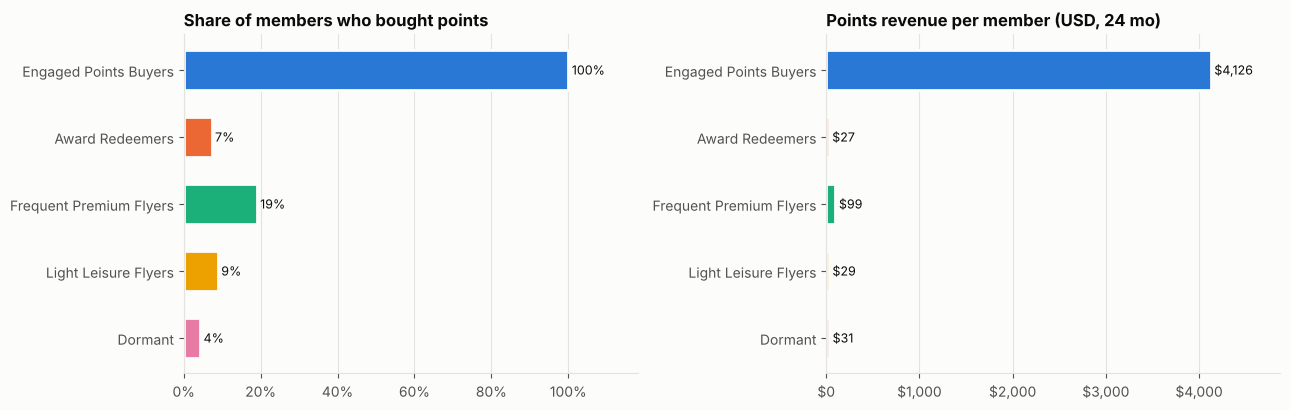

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
metrics = [("buyer_rate", "Share of members who bought points", "{:.0%}"),
           ("revenue_per_member_usd", "Points revenue per member (USD, 24 mo)", "${:,.0f}")]
for ax, (col, title, fmt) in zip(axes, metrics):
    vals = seg[col]
    bars = ax.barh(SEGMENTS[::-1], vals.loc[SEGMENTS[::-1]], height=0.6,
                   color=[SEG_COLOR[s] for s in SEGMENTS[::-1]], edgecolor="#fcfcfb", linewidth=2)
    for b, v in zip(bars, vals.loc[SEGMENTS[::-1]]):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + fmt.format(v),
                va="center", color=INK, fontsize=9)
    ax.set_title(title); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, vals.max() * 1.18)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _, f=fmt: f.format(v)))
plt.tight_layout()

In [20]:
TOP_SEGMENT = seg["revenue_per_member_usd"].idxmax()
top = seg.loc[TOP_SEGMENT]
print(f"Top segment: {TOP_SEGMENT}")
print(f"  {top['share_of_members']:.1%} of members generate {top['share_of_revenue']:.1%} of points revenue")
print(f"  {top['buyer_rate']:.0%} are buyers, averaging {top['purchases_per_member']:.1f} purchases "
      f"and ${top['revenue_per_member_usd']:,.0f} each")

Top segment: Engaged Points Buyers
  10.7% of members generate 93.4% of points revenue
  100% are buyers, averaging 4.6 purchases and $4,126 each


## 8. Propensity model: ranking members inside the top segment
The segment tells us **who to target**. A propensity score tells us **who to contact first**. That matters when the email budget or offer cost is capped.

Setup, using a time split so the model never sees the future:
- **Features** are built as of **2025-06-30** with the same `build_features` function.
- **Label**: did the member buy points from **Jul 1 to Dec 31, 2025**?
- Train on a stratified random 70% of members and evaluate on the other 30% with ROC-AUC and decile lift.
- Then **re-score everyone** with features as of 2025-12-31 to predict the next 6 months.

Logistic regression is enough here. It is easy to explain to a marketing team, and its coefficients show what drives a purchase.

In [21]:
TRAIN_CUTOFF = pd.Timestamp("2025-06-30")
model_features = ["flights", "cash_spend_cad", "points_earned", "points_redeemed", "award_share",
                  "premium_cabin_share", "intl_share", "days_since_booking", "purchases",
                  "points_bought", "days_since_purchase", "promo_share", "tenure_years"]
# points_balance and tier are left out: members.csv stores them as of 2025-12-31, so using them
# with June features would leak information from the label period into the model.

def model_matrix(df):
    m = df[model_features].copy()
    logs = [c for c in log_cols if c in model_features]
    m[logs] = np.log1p(m[logs])
    return m

hist = build_features(TRAIN_CUTOFF, lookback_days=545)  # same 18-month span of history the data allows
future_buyers = purchases.loc[purchases["purchase_date"].between(TRAIN_CUTOFF + pd.Timedelta(days=1), SNAPSHOT),
                              "member_id"].unique()
y = hist.index.isin(future_buyers).astype(int)
print(f"Base rate of buying in H2 2025: {y.mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(model_matrix(hist), y, test_size=0.3,
                                                    stratify=y, random_state=RANDOM_STATE)
propensity_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
propensity_model.fit(X_train, y_train)
test_scores = propensity_model.predict_proba(X_test)[:, 1]
print(f"Hold-out ROC-AUC: {roc_auc_score(y_test, test_scores):.3f}")

Base rate of buying in H2 2025: 8.3%
Hold-out ROC-AUC: 0.892


decile,1,2,3,4,5,6,7,8,9,10
buy_rate,0.54,0.10,0.06,0.04,0.03,0.02,0.01,0.01,0.01,0.01
lift_vs_avg,6.49,1.26,0.77,0.42,0.34,0.27,0.08,0.11,0.12,0.13


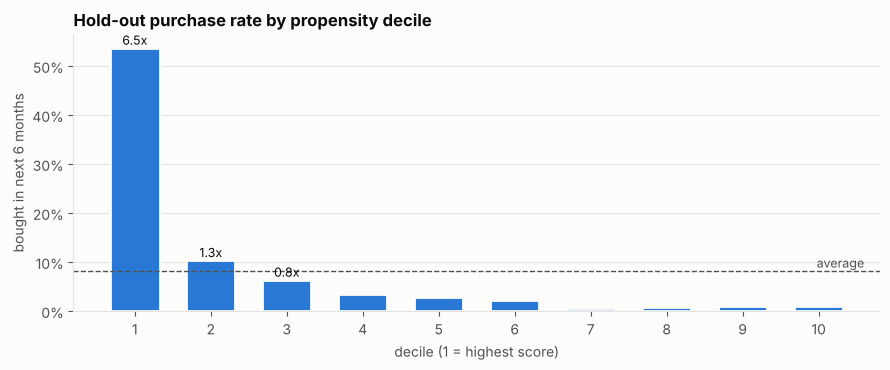

In [22]:
# Lift: how much more often do the top-scored members buy than the average member?
lift = pd.DataFrame({"score": test_scores, "bought": y_test})
lift["decile"] = pd.qcut(lift["score"].rank(method="first", ascending=False), 10, labels=range(1, 11))
lift_tbl = lift.groupby("decile", observed=True)["bought"].mean().to_frame("buy_rate")
lift_tbl["lift_vs_avg"] = lift_tbl["buy_rate"] / lift["bought"].mean()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(lift_tbl.index.astype(str), lift_tbl["buy_rate"], color=PALETTE[0], width=0.65,
       edgecolor="#fcfcfb", linewidth=2)
ax.axhline(lift["bought"].mean(), color=INK_2, ls="--", lw=1)
ax.text(9.6, lift["bought"].mean(), " average", va="bottom", ha="right", color=INK_2, fontsize=9)
for i, (r, l) in enumerate(zip(lift_tbl["buy_rate"], lift_tbl["lift_vs_avg"])):
    if i < 3:
        ax.text(i, r, f"{l:.1f}x", ha="center", va="bottom", fontsize=9, color=INK)
ax.set(title="Hold-out purchase rate by propensity decile", xlabel="decile (1 = highest score)",
       ylabel="bought in next 6 months")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="x", visible=False)
plt.tight_layout()
lift_tbl.T

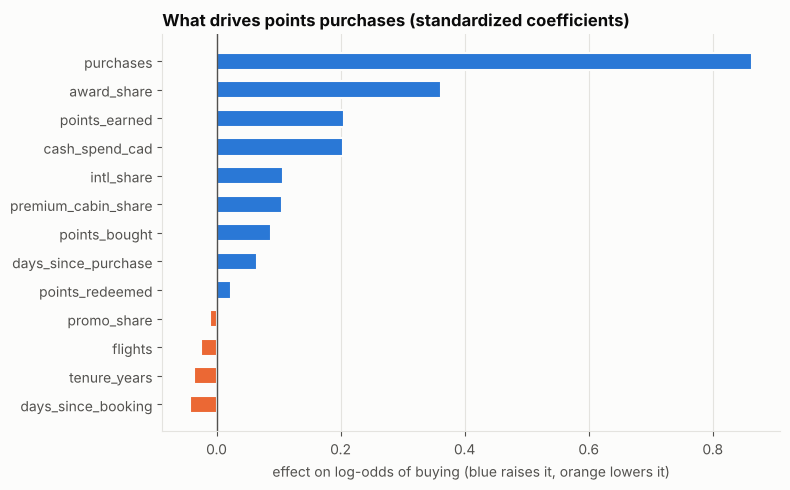

In [23]:
coefs = pd.Series(propensity_model[-1].coef_[0], index=model_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coefs.index, coefs.values, color=[PALETTE[1] if v < 0 else PALETTE[0] for v in coefs],
        height=0.6, edgecolor="#fcfcfb", linewidth=1.5)
ax.axvline(0, color=INK_2, lw=1)
ax.set(title="What drives points purchases (standardized coefficients)",
       xlabel="effect on log-odds of buying (blue raises it, orange lowers it)")
ax.grid(axis="y", visible=False)
plt.tight_layout()

Past buying is by far the strongest signal: members who have bought before buy again. **Award share** comes next. Members who book flights with points run their balances down and top up. Cash flying and earning help a little; flight count and tenure add almost nothing once the other features are in.

*Caveat:* the buying features (`purchases`, `points_bought`, `days_since_purchase`) are highly correlated, so their individual coefficients should not be read one at a time. For example, `days_since_purchase` shows a small positive weight only because `purchases` already carries the effect. Read them as a group.

## 9. Target list: top segment, not yet marketed to
Final filters:
1. Member is in the **top segment**.
2. Member has **opted in to email** (we can legally contact them).
3. Member has **never received a points campaign**.

Eligible members are then ranked by propensity score.

In [24]:
features["propensity"] = propensity_model.predict_proba(model_matrix(features))[:, 1]
contacted_ids = set(contacts["member_id"])
features["previously_contacted"] = features.index.isin(contacted_ids)

in_top = features["segment"] == TOP_SEGMENT
opted_in = in_top & features["email_opt_in"]
not_contacted = opted_in & ~features["previously_contacted"]

funnel = pd.Series({
    "All members": len(features),
    f"Top segment ({TOP_SEGMENT})": in_top.sum(),
    "  ...and email opt-in": opted_in.sum(),
    "  ...and never contacted": not_contacted.sum(),
}, name="members").to_frame()
funnel

,members
All members,40000
Top segment (Engaged Points Buyers),4283
...and email opt-in,3349
...and never contacted,1890


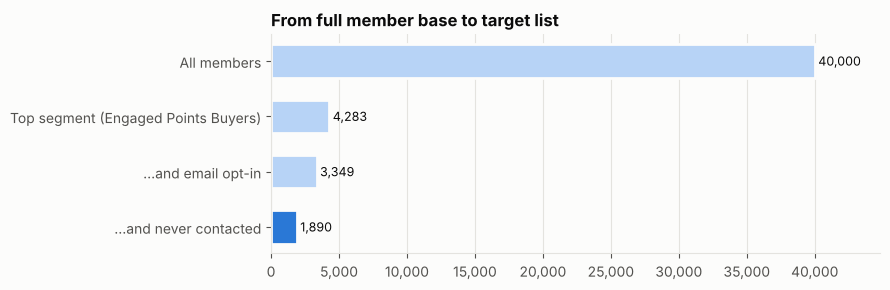

In [25]:
fig, ax = plt.subplots(figsize=(9, 3))
labels = funnel.index[::-1]
vals = funnel["members"].iloc[::-1]
bars = ax.barh(labels, vals, color=[PALETTE[0]] + ["#b7d3f6"] * 3, height=0.6,
               edgecolor="#fcfcfb", linewidth=2)
for b, v in zip(bars, vals):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f" {v:,}", va="center", fontsize=9, color=INK)
ax.set_xlim(right=vals.max() * 1.12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("From full member base to target list")
ax.grid(axis="y", visible=False)
plt.tight_layout()

In [26]:
# Does contact history explain anything? Compare contacted vs. never-contacted within the top segment
features[in_top].groupby("previously_contacted").agg(
    members=("propensity", "size"),
    avg_propensity=("propensity", "mean"),
    buyer_rate=("purchases", lambda s: (s > 0).mean()),
    avg_purchases=("purchases", "mean"),
)

,members,avg_propensity,buyer_rate,avg_purchases
previously_contacted,,,,
False,2824,0.58,1.00,4.58
True,1459,0.59,1.00,4.65


Never-contacted members in the top segment look almost the same as the contacted ones: similar propensity and similar past buying. These are members with high purchase intent who have **organically** bought points without being emailed. That makes them the clearest incremental marketing opportunity.

In [27]:
target_list = (features[not_contacted]
               .assign(propensity_tier=lambda d: pd.qcut(d["propensity"].rank(method="first"), 3,
                                                          labels=["Low", "Medium", "High"]))
               .sort_values("propensity", ascending=False)
               [["segment", "tier", "propensity", "propensity_tier", "flights", "points_redeemed",
                 "purchases", "purchase_spend_usd", "days_since_purchase", "points_balance",
                 "home_airport"]]
               .round({"propensity": 4}))

Path("output").mkdir(exist_ok=True)
target_list.to_csv("output/target_list.csv")
features[["segment", "propensity", "previously_contacted", "email_opt_in"]].to_csv("output/member_segments.csv")
print(f"Saved {len(target_list):,} members to output/target_list.csv")
target_list.head(10)

Saved 1,890 members to output/target_list.csv


,segment,tier,propensity,propensity_tier,flights,points_redeemed,purchases,purchase_spend_usd,days_since_purchase,points_balance,home_airport
member_id,,,,,,,,,,,
M0037799,Engaged Points Buyers,Base,1.00,High,23.00,"996,900.00",48.00,"43,923.25",17.00,1094183,YYZ
M0018195,Engaged Points Buyers,Silver,0.99,High,14.00,"930,100.00",36.00,"29,474.04",3.00,493568,YYZ
M0006872,Engaged Points Buyers,Base,0.99,High,12.00,"841,300.00",31.00,"35,432.33",32.00,901996,YYZ
M0034658,Engaged Points Buyers,Elite,0.99,High,7.00,"633,100.00",29.00,"27,901.90",14.00,595963,YUL
M0027556,Engaged Points Buyers,Gold,0.99,High,25.00,"1,206,800.00",35.00,"30,141.36",92.00,181481,YVR
M0021688,Engaged Points Buyers,Silver,0.99,High,18.00,"1,217,400.00",35.00,"30,393.76",18.00,232629,YUL
M0002251,Engaged Points Buyers,Silver,0.99,High,29.00,"1,569,400.00",27.00,"25,398.26",9.00,0,YYZ
M0014558,Engaged Points Buyers,Gold,0.99,High,14.00,"1,076,100.00",24.00,"23,802.90",38.00,187626,YYZ
M0011896,Engaged Points Buyers,Platinum,0.99,High,11.00,"641,300.00",22.00,"21,018.37",29.00,312646,YEG


In [28]:
target_list.groupby("propensity_tier", observed=True).agg(
    members=("propensity", "size"),
    avg_propensity=("propensity", "mean"),
    avg_past_spend_usd=("purchase_spend_usd", "mean"),
).sort_index(ascending=False)

,members,avg_propensity,avg_past_spend_usd
propensity_tier,,,
High,630,0.89,"8,861.08"
Medium,630,0.60,"2,776.74"
Low,630,0.26,758.93


## 10. Takeaways & recommendations
- **The top segment is small but drives most points revenue.** *Engaged Points Buyers* make up about a tenth of members but account for the majority of points-purchase revenue. Redemption activity is what sets them apart: they spend points on award flights and buy more to cover the gap.
- **A large share of this segment has never been marketed to.** The target list holds opted-in, high-propensity members with no campaign history. They are the best candidates for an incremental points campaign.
- **Prioritize by propensity tier.** If the send is capped, start with the *High* tier. If running a test, hold out a random control within each tier to measure true incremental lift instead of crediting the campaign with organic purchases.
- **Messaging:** frame offers around redemption (e.g. "top up for your next award trip"), since redemption activity is the strongest behavioural driver after past purchasing.
- **Second wave:** *Award Redeemers* already value redemptions and have drained their balances. A "top up for your next trip" offer timed after a redemption is a good next audience. Score them with the same propensity model.
- **Other segments:** *Frequent Premium Flyers* earn enough that a points-sale message will rarely land, so status or upgrade offers may work better. *Dormant* members need reactivation, not a sale.

**Next steps for a production version:** refresh segments monthly, monitor segment drift, and measure campaign results with randomized holdouts.